# Task 4 — Step 4: Active Learning Loop

Trains a 4-classifier ensemble on string-similarity features, queries the 100 most uncertain candidates from the unlabeled pool each iteration, labels them with Claude `claude-sonnet-4-6`, and repeats for 20 iterations.

**Ensemble** (Steiner & Bizer 2026): RandomForest · XGBoost · GradientBoosting · LogisticRegression

**Uncertainty** = variance of predicted match probability across the 4 classifiers

**Initial training set** = existing `train.txt` + 100 seed pairs from Step 3.

**Output**: `data/processed/<dataset>/al_labeled.jsonl` (appended each iteration) and `train_aug_llm.txt` (Ditto-format training file).

**Resumable**: interrupt and re-run — existing `al_labeled.jsonl` is detected and the loop continues from where it left off.

Change only `DATASET` to switch between datasets.

## Configuration

In [13]:
DATASET      = "wdc-products"    # "dblp-scholar" | "wdc-products"
N_ITERATIONS = 20                # active learning iterations
BATCH_SIZE   = 100               # pairs to label per iteration
LLM_MODEL    = "claude-sonnet-4-6"

## Imports & paths

In [14]:
import json
import re
import sys
import time
from pathlib import Path

import anthropic
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from dotenv import load_dotenv
from jellyfish import jaro_winkler_similarity
from rapidfuzz import fuzz
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression

ROOT      = Path("../").resolve()
sys.path.insert(0, str(ROOT))

PROCESSED = ROOT / "data" / "processed" / DATASET
AL_OUTPUT = PROCESSED / "al_labeled.jsonl"

load_dotenv(ROOT / ".env")
# max_retries lets the SDK auto-retry transient API errors (429 rate-limit,
# 5xx, and 529 "overloaded") with exponential backoff + jitter. label_pair adds
# a second backoff layer on top for sustained overloads.
client = anthropic.Anthropic(max_retries=8)

print(f"Dataset : {DATASET}")
print(f"AL output : {AL_OUTPUT}")
print(f"Iterations : {N_ITERATIONS} × {BATCH_SIZE} pairs = {N_ITERATIONS * BATCH_SIZE} new labels")

Dataset : wdc-products
AL output : /Users/abd/Developer/thesis-project/data/processed/wdc-products/al_labeled.jsonl
Iterations : 20 × 100 pairs = 2000 new labels


## Feature extraction

In [15]:
FEATURE_NAMES = ["jaccard_tok", "jaccard_char", "jaro_winkler", "lev_ratio", "tok_set_ratio", "embed_cosine"]


def strip_col_val(text: str) -> str:
    return re.sub(r"COL \S+ VAL\s*", " ", str(text)).strip()


def compute_features(left: str, right: str, sim_score: float) -> list:
    lv = strip_col_val(left).lower()
    rv = strip_col_val(right).lower()

    lt = set(lv.split())
    rt = set(rv.split())
    union_t = lt | rt
    jaccard_tok = len(lt & rt) / len(union_t) if union_t else 0.0

    lb = {lv[i:i+2] for i in range(len(lv) - 1)}
    rb = {rv[i:i+2] for i in range(len(rv) - 1)}
    union_b = lb | rb
    jaccard_char = len(lb & rb) / len(union_b) if union_b else 0.0

    jaro_wink = jaro_winkler_similarity(lv[:500], rv[:500])  # cap at 500 chars for speed
    lev_ratio = fuzz.ratio(lv[:500], rv[:500]) / 100.0
    tok_set   = fuzz.token_set_ratio(lv, rv) / 100.0

    return [jaccard_tok, jaccard_char, jaro_wink, lev_ratio, tok_set, float(sim_score)]


print("Feature function defined. Example:")
ex = compute_features("COL title VAL database systems", "COL title VAL database management systems", 0.9)
for name, val in zip(FEATURE_NAMES, ex):
    print(f"  {name:20s}: {val:.4f}")

Feature function defined. Example:
  jaccard_tok         : 0.6667
  jaccard_char        : 0.6000
  jaro_winkler        : 0.8810
  lev_ratio           : 0.7442
  tok_set_ratio       : 1.0000
  embed_cosine        : 0.9000


## Load data

In [16]:
# Candidate pool
pool = pd.read_csv(PROCESSED / "candidates_pool.csv")
pool["id1"] = pool["id1"].astype(int)
pool["id2"] = pool["id2"].astype(int)

# Entity text lookups
left_text  = pd.read_csv(PROCESSED / "entities_left.csv").set_index("id")["text"].to_dict()
right_text = pd.read_csv(PROCESSED / "entities_right.csv").set_index("id")["text"].to_dict()

# Seed pairs from Step 3
seed = [json.loads(l) for l in open(PROCESSED / "seed_labeled.jsonl")]
print(f"Seed pairs: {len(seed)}  (pos={sum(r['label']==1 for r in seed)})")

# Existing train.txt ground-truth labels
def load_txt_pairs(path: Path) -> list[dict]:
    rows = []
    for line in open(path):
        parts = line.rstrip("\n").split("\t")
        if len(parts) == 3:
            rows.append({"left_text": parts[0], "right_text": parts[1],
                         "label": int(parts[2]), "sim_score": 0.5})
    return rows

existing_train = load_txt_pairs(PROCESSED / "train.txt")
n_pos_train = sum(r["label"]==1 for r in existing_train)
print(f"Existing train: {len(existing_train)} pairs  (pos={n_pos_train}, {n_pos_train/len(existing_train)*100:.1f}%)")
print(f"Pool size: {len(pool):,} candidate pairs")

Seed pairs: 100  (pos=7)
Existing train: 2500 pairs  (pos=500, 20.0%)
Pool size: 4,722 candidate pairs


## Resume check

In [17]:
al_labeled = []
already_labeled = {(r["id1"], r["id2"]) for r in seed}
start_iter = 0

if AL_OUTPUT.exists():
    for line in open(AL_OUTPUT):
        rec = json.loads(line)
        al_labeled.append(rec)
        already_labeled.add((rec["id1"], rec["id2"]))

    # Infer which iteration to start from
    iter_nums = [
        int(m.group(1))
        for r in al_labeled
        for m in [re.search(r"al_iter(\d+)", r.get("source", ""))]
        if m
    ]
    start_iter = max(iter_nums) if iter_nums else 0
    print(f"Resuming from iteration {start_iter + 1}  ({len(al_labeled)} AL pairs already labeled)")
else:
    print("Starting fresh — no existing AL output found")

# Build pool_remaining: remove all already-labeled pairs
labeled_key_set = {f"{a}_{b}" for a, b in already_labeled}
pool["_key"] = pool["id1"].astype(str) + "_" + pool["id2"].astype(str)
pool_remaining = pool[~pool["_key"].isin(labeled_key_set)].drop(columns=["_key"]).reset_index(drop=True)
pool = pool.drop(columns=["_key"])
print(f"Pool remaining: {len(pool_remaining):,} unlabeled pairs")

Resuming from iteration 1  (0 AL pairs already labeled)
Pool remaining: 4,622 unlabeled pairs


## Ensemble definition

In [18]:
def make_ensemble() -> dict:
    return {
        "rf":  RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced"),
        "xgb": xgb.XGBClassifier(n_estimators=100, random_state=42,
                                   eval_metric="logloss", verbosity=0),
        "gb":  GradientBoostingClassifier(n_estimators=100, random_state=42),
        "lr":  LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    }


def train_ensemble(ensemble: dict, X: np.ndarray, y: np.ndarray) -> None:
    for name, clf in ensemble.items():
        clf.fit(X, y)


def predict_proba_all(ensemble: dict, X: np.ndarray) -> np.ndarray:
    """Returns shape (n_classifiers, n_samples) — match probability per classifier."""
    return np.array([clf.predict_proba(X)[:, 1] for clf in ensemble.values()])


print("Ensemble defined:", list(make_ensemble().keys()))

Ensemble defined: ['rf', 'xgb', 'gb', 'lr']


## LLM labeling function

In [19]:
def build_prompt(left: str, right: str) -> str:
    if DATASET == "dblp-scholar":
        return (
            "You are labeling pairs of academic paper records for entity matching.\n"
            "Decide if LEFT and RIGHT refer to the exact same paper "
            "(same title, same authors, same publication).\n\n"
            f"LEFT:  {left}\n"
            f"RIGHT: {right}\n\n"
            'Reply with valid JSON only — no markdown, no extra text:\n'
            '{"label": 1, "reasoning": "one sentence"}  ← same paper\n'
            '{"label": 0, "reasoning": "one sentence"}  ← different papers'
        )
    else:
        return (
            "You are labeling pairs of e-commerce product listings for entity matching.\n"
            "Decide if LEFT and RIGHT refer to the exact same product "
            "(same model, variant, and specs — not just the same product line).\n"
            "Pay close attention to: color, storage/memory capacity, size/dimensions, "
            "bundle contents, edition/version, and model number.\n\n"
            f"LEFT:  {left}\n"
            f"RIGHT: {right}\n\n"
            'Reply with valid JSON only — no markdown, no extra text:\n'
            '{"label": 1, "reasoning": "one sentence"}  ← same product\n'
            '{"label": 0, "reasoning": "one sentence"}  ← different products'
        )


def label_pair(id1: int, id2: int, sim_score: float, source: str) -> dict | None:
    left  = left_text[id1]
    right = right_text[id2]
    max_attempts = 8
    for attempt in range(max_attempts):
        try:
            resp = client.messages.create(
                model=LLM_MODEL,
                max_tokens=128,
                messages=[{"role": "user", "content": build_prompt(left, right)}],
            )
            result = json.loads(resp.content[0].text.strip())
            return {
                "id1": int(id1),
                "id2": int(id2),
                "sim_score": round(float(sim_score), 6),
                "left_text": left,
                "right_text": right,
                "label": int(result["label"]),
                "reasoning": str(result.get("reasoning", "")),
                "model": LLM_MODEL,
                "source": source,
            }
        except (json.JSONDecodeError, KeyError):
            # Malformed reply — quick retry, give up after the last attempt.
            if attempt == max_attempts - 1:
                print(f"  [warn] JSON parse failed for ({id1}, {id2}) — skipping")
                return None
            time.sleep(1)
        except anthropic.APIError as e:
            # Transient API errors incl. 529 overloaded / 429 rate-limit / 5xx /
            # connection drops. Exponential backoff (capped at 60s) then retry.
            if attempt == max_attempts - 1:
                print(f"  [warn] API error for ({id1}, {id2}) after {max_attempts} attempts ({e}) — skipping")
                return None
            wait = min(60, 2 ** attempt)
            print(f"  [retry] API overloaded/error on ({id1}, {id2}) — backoff {wait}s")
            time.sleep(wait)


print("LLM labeling function defined.")

LLM labeling function defined.


## Active learning loop

Each iteration:
1. Build feature matrix from all labeled data (existing train + seed + AL so far)
2. Train 4-classifier ensemble
3. Score unlabeled pool by classifier variance (uncertainty)
4. Label top-100 most uncertain pairs with the LLM
5. Add to labeled set, remove from pool

In [20]:
iter_stats = []   # [(iteration, n_pos, n_neg)] for the learning curve
ensemble_final = None  # keep last-iteration ensemble for feature importance

with open(AL_OUTPUT, "a") as out_f:
    for iteration in range(start_iter, N_ITERATIONS):
        print(f"\n{'='*60}")
        print(f"  Iteration {iteration + 1}/{N_ITERATIONS}")
        print(f"{'='*60}")

        if len(pool_remaining) == 0:
            print("  Pool exhausted — stopping early.")
            break

        # --- Build training feature matrix ---
        all_labeled = existing_train + seed + al_labeled
        print(f"  Training on {len(all_labeled)} labeled pairs "
              f"(pos={sum(r['label']==1 for r in all_labeled)})")

        X_train = np.array([
            compute_features(r["left_text"], r["right_text"], r.get("sim_score") or 0.5)
            for r in all_labeled
        ])
        y_train = np.array([r["label"] for r in all_labeled])

        # --- Train ensemble ---
        ensemble = make_ensemble()
        train_ensemble(ensemble, X_train, y_train)
        ensemble_final = ensemble
        print(f"  Ensemble trained.")

        # --- Score unlabeled pool ---
        X_pool = np.array([
            compute_features(left_text[int(r.id1)], right_text[int(r.id2)], r.sim_score)
            for _, r in pool_remaining.iterrows()
        ])
        probas   = predict_proba_all(ensemble, X_pool)   # (4, N)
        variance = probas.var(axis=0)                    # (N,)

        # Select top-BATCH_SIZE by variance
        top_idx   = np.argsort(variance)[::-1][:BATCH_SIZE]
        query_rows = pool_remaining.iloc[top_idx]
        print(f"  Selected {len(query_rows)} pairs  "
              f"(variance range [{variance[top_idx[-1]]:.4f}, {variance[top_idx[0]]:.4f}])")

        # --- LLM labeling ---
        iter_labeled = []
        for q_i, (_, row) in enumerate(query_rows.iterrows()):
            record = label_pair(
                int(row.id1), int(row.id2), row.sim_score,
                source=f"al_iter{iteration + 1}"
            )
            if record is None:
                continue
            iter_labeled.append(record)
            al_labeled.append(record)
            already_labeled.add((record["id1"], record["id2"]))
            out_f.write(json.dumps(record) + "\n")
            out_f.flush()

            if (q_i + 1) % 20 == 0:
                n_pos_so_far = sum(r["label"]==1 for r in iter_labeled)
                print(f"  [{q_i+1:3d}/{BATCH_SIZE}] labeled so far — "
                      f"pos={n_pos_so_far}/{len(iter_labeled)}")

        # --- Remove labeled pairs from pool ---
        new_key_set = {f"{r['id1']}_{r['id2']}" for r in iter_labeled}
        pool_remaining["_key"] = (pool_remaining["id1"].astype(str) + "_" +
                                   pool_remaining["id2"].astype(str))
        pool_remaining = (
            pool_remaining[~pool_remaining["_key"].isin(new_key_set)]
            .drop(columns=["_key"])
            .reset_index(drop=True)
        )

        n_pos_iter = sum(r["label"]==1 for r in iter_labeled)
        n_neg_iter = len(iter_labeled) - n_pos_iter
        iter_stats.append((iteration + 1, n_pos_iter, n_neg_iter))
        print(f"  Iteration result: pos={n_pos_iter}  neg={n_neg_iter}  "
              f"({n_pos_iter/len(iter_labeled)*100:.1f}% positive)")
        print(f"  Pool remaining : {len(pool_remaining):,}")
        print(f"  Total AL labeled so far: {len(al_labeled)}")

print(f"\nActive learning loop complete.")
print(f"Total AL pairs labeled: {len(al_labeled)}")


  Iteration 1/20
  Training on 2600 labeled pairs (pos=507)
  Ensemble trained.
  Selected 100 pairs  (variance range [0.0550, 0.1191])
  [ 20/100] labeled so far — pos=5/20
  [ 40/100] labeled so far — pos=9/40
  [ 60/100] labeled so far — pos=12/60
  [ 80/100] labeled so far — pos=12/80
  [100/100] labeled so far — pos=13/100
  Iteration result: pos=13  neg=87  (13.0% positive)
  Pool remaining : 4,522
  Total AL labeled so far: 100

  Iteration 2/20
  Training on 2700 labeled pairs (pos=520)
  Ensemble trained.
  Selected 100 pairs  (variance range [0.0512, 0.1109])
  [ 20/100] labeled so far — pos=6/20
  [ 40/100] labeled so far — pos=10/40
  [ 60/100] labeled so far — pos=18/60
  [ 80/100] labeled so far — pos=20/80
  [100/100] labeled so far — pos=23/100
  Iteration result: pos=23  neg=77  (23.0% positive)
  Pool remaining : 4,422
  Total AL labeled so far: 200

  Iteration 3/20
  Training on 2800 labeled pairs (pos=543)
  Ensemble trained.
  Selected 100 pairs  (variance range 

## Save final training file (Ditto format)

In [21]:
all_new = seed + al_labeled
train_aug_path = PROCESSED / "train_aug_llm.txt"

with open(train_aug_path, "w") as f:
    # Existing train pairs unchanged
    for line in open(PROCESSED / "train.txt"):
        f.write(line)
    # Append all new LLM-labeled pairs
    for r in all_new:
        f.write(f"{r['left_text']}\t{r['right_text']}\t{r['label']}\n")

total = len(existing_train) + len(all_new)
n_pos_all = sum(r["label"]==1 for r in existing_train) + sum(r["label"]==1 for r in all_new)
print(f"Saved → {train_aug_path}")
print(f"  Total pairs : {total:,}")
print(f"  Positives : {n_pos_all} ({n_pos_all/total*100:.1f}%)")
print(f"  Negatives : {total - n_pos_all} ({(total-n_pos_all)/total*100:.1f}%)")

Saved → /Users/abd/Developer/thesis-project/data/processed/wdc-products/train_aug_llm.txt
  Total pairs : 4,600
  Positives : 717 (15.6%)
  Negatives : 3883 (84.4%)


## Final statistics

In [22]:
n_seed = len(seed)
n_al = len(al_labeled)
n_total = n_seed + n_al
n_pos_new = sum(r["label"]==1 for r in all_new)
n_neg_new = n_total - n_pos_new

estimated_cost = n_total * (300 * 3e-6 + 30 * 15e-6)

print(f"{'Metric':<35} {'Value':>12}")
print("-" * 49)
print(f"{'Seed pairs (Step 3)':<35} {n_seed:>12}")
print(f"{'AL pairs (Step 4)':<35} {n_al:>12}")
print(f"{'Total new LLM-labeled pairs':<35} {n_total:>12}")
print(f"{'  Positives':<35} {n_pos_new:>12}  ({n_pos_new/n_total*100:.1f}%)")
print(f"{'  Negatives':<35} {n_neg_new:>12}  ({n_neg_new/n_total*100:.1f}%)")
print(f"{'Iterations completed':<35} {len(iter_stats):>12}")
print(f"{'Estimated API cost':<35} {'$'+f'{estimated_cost:.3f}':>12}")

Metric                                     Value
-------------------------------------------------
Seed pairs (Step 3)                          100
AL pairs (Step 4)                           2000
Total new LLM-labeled pairs                 2100
  Positives                                  217  (10.3%)
  Negatives                                 1883  (89.7%)
Iterations completed                          20
Estimated API cost                        $2.835


dblp
  Positives                                   41  (2.0%)
  Negatives                                 2059  (98.0%)

## Per-iteration learning curve

In [ ]:
FIGURES = PROCESSED / DATASET / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

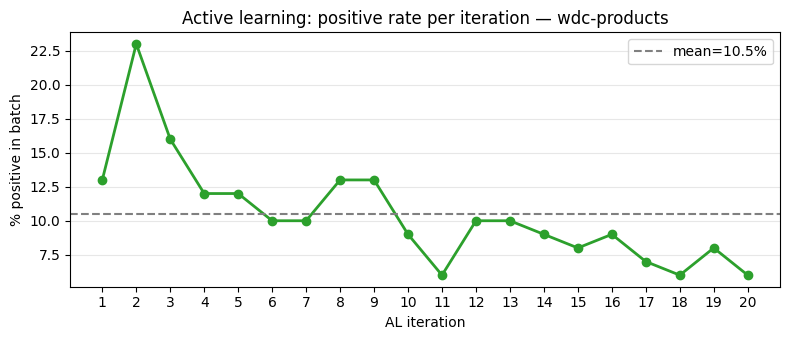

Mean positive rate across iterations: 10.5%


In [ ]:
if iter_stats:
    iters    = [s[0] for s in iter_stats]
    pos_rates = [s[1] / (s[1] + s[2]) * 100 for s in iter_stats]

    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.plot(iters, pos_rates, marker="o", color="#2ca02c", linewidth=2)
    ax.axhline(np.mean(pos_rates), color="gray", linestyle="--",
               label=f"mean={np.mean(pos_rates):.1f}%")
    ax.set_xlabel("AL iteration")
    ax.set_ylabel("% positive in batch")
    ax.set_title(f"Active learning: positive rate per iteration — {DATASET}")
    ax.set_xticks(iters)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES / f"al_positive_rate_{DATASET}.png")
    plt.show()

    print(f"Mean positive rate across iterations: {np.mean(pos_rates):.1f}%")
    if np.mean(pos_rates) < 5:
        print("[WARNING] Very low positive rate — AL may be selecting pairs the LLM consistently labels as non-matches.")

## Feature importance (Random Forest)

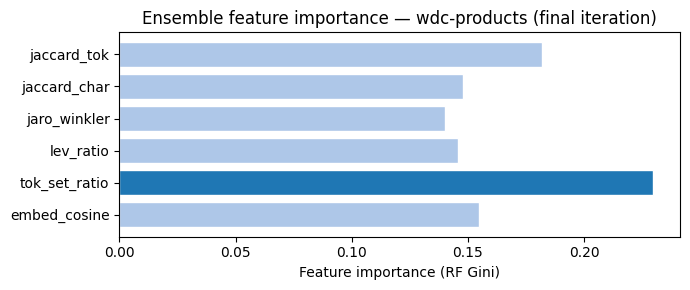

Feature importances:
  tok_set_ratio       : 0.2298
  jaccard_tok         : 0.1821
  embed_cosine        : 0.1547
  jaccard_char        : 0.1477
  lev_ratio           : 0.1458
  jaro_winkler        : 0.1400


In [ ]:
if ensemble_final is not None:
    rf = ensemble_final["rf"]
    importances = rf.feature_importances_

    fig, ax = plt.subplots(figsize=(7, 3))
    colors = ["#1f77b4" if imp == max(importances) else "#aec7e8" for imp in importances]
    ax.barh(FEATURE_NAMES, importances, color=colors, edgecolor="white")
    ax.set_xlabel("Feature importance (RF Gini)")
    ax.set_title(f"Ensemble feature importance — {DATASET} (final iteration)")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(FIGURES / f"al_feature_importance_{DATASET}.png")
    plt.show()

    print("Feature importances:")
    for name, imp in sorted(zip(FEATURE_NAMES, importances), key=lambda x: -x[1]):
        print(f"  {name:20s}: {imp:.4f}")